# TP02 - Reseaux avances (Fashion-MNIST) - **TensorFlow / Keras**

**M2 DMIA - Deep Learning - Session 2**

Objectif : comparer un reseau dense profond **SANS** vs **AVEC** regularisation (batch norm + dropout) sur **Fashion-MNIST**, et **voir** le sur-apprentissage sur les courbes train/validation.

Pipeline DL : 1. Charger -> 2. Pretraiter -> 3. Modele -> 4. Perte + optimiseur -> 5. Entrainer -> 6. Evaluer -> 7. Analyser.

> Recommande : executer sur **Google Colab** (Execution -> Modifier le type d'execution -> GPU).

## 0. Imports et reproductibilite

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilite
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)

TensorFlow version : 2.21.0


## 1. Charger les donnees

Fashion-MNIST est integre a Keras : 60 000 images d'entrainement et 10 000 de test, en niveaux de gris 28x28, reparties en 10 classes de vetements.

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Pantalon', 'Pull', 'Robe', 'Manteau',
               'Sandale', 'Chemise', 'Basket', 'Sac', 'Bottine']

print('x_train :', x_train.shape, '| y_train :', y_train.shape)
print('x_test  :', x_test.shape,  '| y_test  :', y_test.shape)
print('valeurs des pixels : min =', x_train.min(), ', max =', x_train.max())

x_train : (60000, 28, 28) | y_train : (60000,)
x_test  : (10000, 28, 28) | y_test  : (10000,)
valeurs des pixels : min = 0 , max = 255


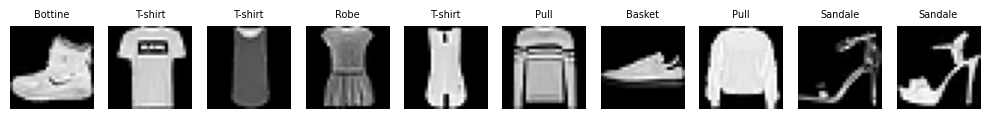

In [4]:
# Visualisons quelques exemples
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=7)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Pretraiter

On **normalise** les pixels de [0, 255] vers [0, 1]. Les labels restent en entiers (0-9) : on utilisera la perte `sparse_categorical_crossentropy`.

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

print('Apres normalisation : min =', x_train.min(), ', max =', x_train.max())

Apres normalisation : min = 0.0 , max = 1.0


## 3. Deux modeles de meme architecture

On construit deux reseaux denses profonds `784 -> 256 -> 128 -> 64 -> 10` :
- **Modele A (baseline)** : sans regularisation.
- **Modele B (regularise)** : memes couches + **BatchNormalization** + **Dropout**.

> But : observer que A **sur-apprend** (val_loss qui remonte) et que B **generalise mieux**.

In [6]:
def build_baseline():
    return keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='baseline')

def build_regularized(dropout_rate=0.3):
    return keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ], name='regularized')

model_a = build_baseline()
model_b = build_regularized(0.3)
model_a.summary()
model_b.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Model: "regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Compiler (perte + optimiseur)

Meme configuration pour les deux modeles : optimiseur **Adam**, perte **sparse_categorical_crossentropy**, metrique **accuracy**. Ainsi, la seule difference est la **regularisation**.

In [7]:
for m in (model_a, model_b):
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 5. Entrainer les deux modeles

On entraine sur **30 epoques** avec 10 % de validation. Un nombre d'epoques eleve aide a **faire apparaitre** le sur-apprentissage de la baseline.

In [8]:
EPOCHS = 30

hist_a = model_a.fit(x_train, y_train, epochs=EPOCHS, batch_size=128,
                     validation_split=0.1, verbose=2)
hist_b = model_b.fit(x_train, y_train, epochs=EPOCHS, batch_size=128,
                     validation_split=0.1, verbose=2)

Epoch 1/30
422/422 - 2s - 6ms/step - accuracy: 0.8106 - loss: 0.5389 - val_accuracy: 0.8572 - val_loss: 0.4022
Epoch 2/30
422/422 - 1s - 3ms/step - accuracy: 0.8628 - loss: 0.3779 - val_accuracy: 0.8697 - val_loss: 0.3521
Epoch 3/30
422/422 - 1s - 3ms/step - accuracy: 0.8774 - loss: 0.3352 - val_accuracy: 0.8755 - val_loss: 0.3413
Epoch 4/30
422/422 - 1s - 3ms/step - accuracy: 0.8872 - loss: 0.3064 - val_accuracy: 0.8783 - val_loss: 0.3359
Epoch 5/30
422/422 - 1s - 3ms/step - accuracy: 0.8944 - loss: 0.2856 - val_accuracy: 0.8778 - val_loss: 0.3404
Epoch 6/30
422/422 - 1s - 3ms/step - accuracy: 0.8990 - loss: 0.2711 - val_accuracy: 0.8792 - val_loss: 0.3489
Epoch 7/30
422/422 - 2s - 4ms/step - accuracy: 0.9042 - loss: 0.2568 - val_accuracy: 0.8780 - val_loss: 0.3552
Epoch 8/30
422/422 - 1s - 3ms/step - accuracy: 0.9072 - loss: 0.2459 - val_accuracy: 0.8747 - val_loss: 0.3682
Epoch 9/30
422/422 - 1s - 3ms/step - accuracy: 0.9108 - loss: 0.2360 - val_accuracy: 0.8790 - val_loss: 0.3590
E

## 6. Comparer les courbes train vs validation

C'est le coeur du TP : on superpose les pertes des deux modeles. La courbe **val_loss** de la baseline devrait **remonter** (sur-apprentissage) ; celle du modele regularise devrait **rester plus basse**.

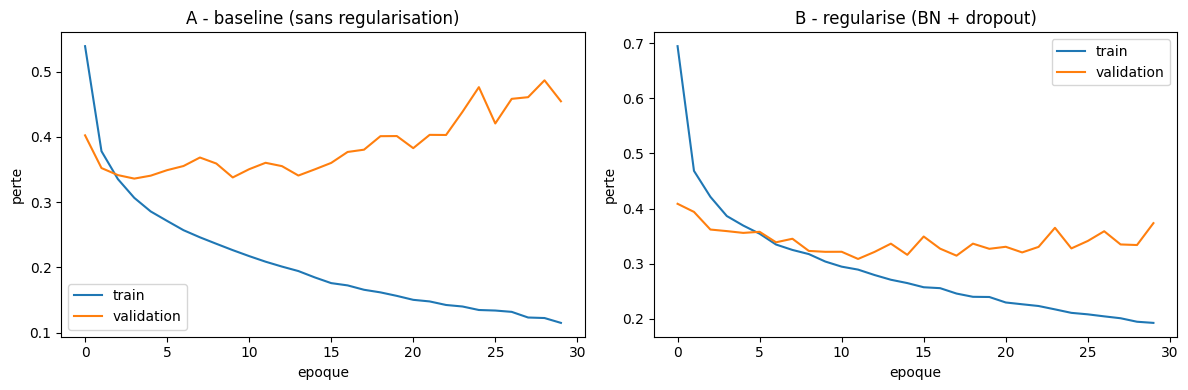

In [9]:
def plot_history(hist, title):
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='validation')
    plt.title(title); plt.xlabel('epoque'); plt.ylabel('perte'); plt.legend()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plot_history(hist_a, 'A - baseline (sans regularisation)')
plt.subplot(1, 2, 2)
plot_history(hist_b, 'B - regularise (BN + dropout)')
plt.tight_layout(); plt.show()

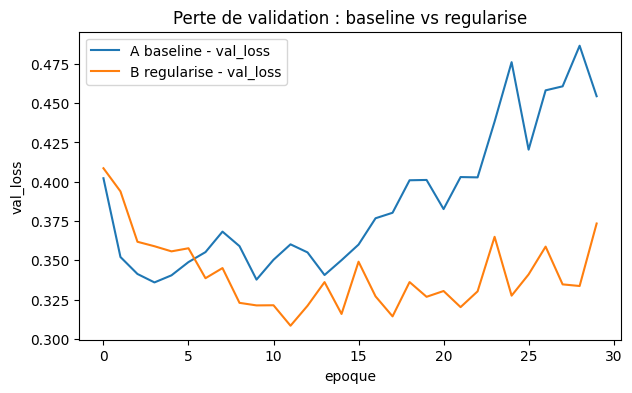

In [10]:
# Comparaison directe des val_loss
plt.figure(figsize=(7, 4))
plt.plot(hist_a.history['val_loss'], label='A baseline - val_loss')
plt.plot(hist_b.history['val_loss'], label='B regularise - val_loss')
plt.title('Perte de validation : baseline vs regularise')
plt.xlabel('epoque'); plt.ylabel('val_loss'); plt.legend()
plt.show()

## 7. Evaluer sur le jeu de test

In [11]:
loss_a, acc_a = model_a.evaluate(x_test, y_test, verbose=0)
loss_b, acc_b = model_b.evaluate(x_test, y_test, verbose=0)

print(f'A baseline   : accuracy test = {acc_a:.4f}  (perte {loss_a:.4f})')
print(f'B regularise : accuracy test = {acc_b:.4f}  (perte {loss_b:.4f})')

A baseline   : accuracy test = 0.8792  (perte 0.4898)
B regularise : accuracy test = 0.8791  (perte 0.3968)


## 8. Analyser : matrice de confusion (modele regularise)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


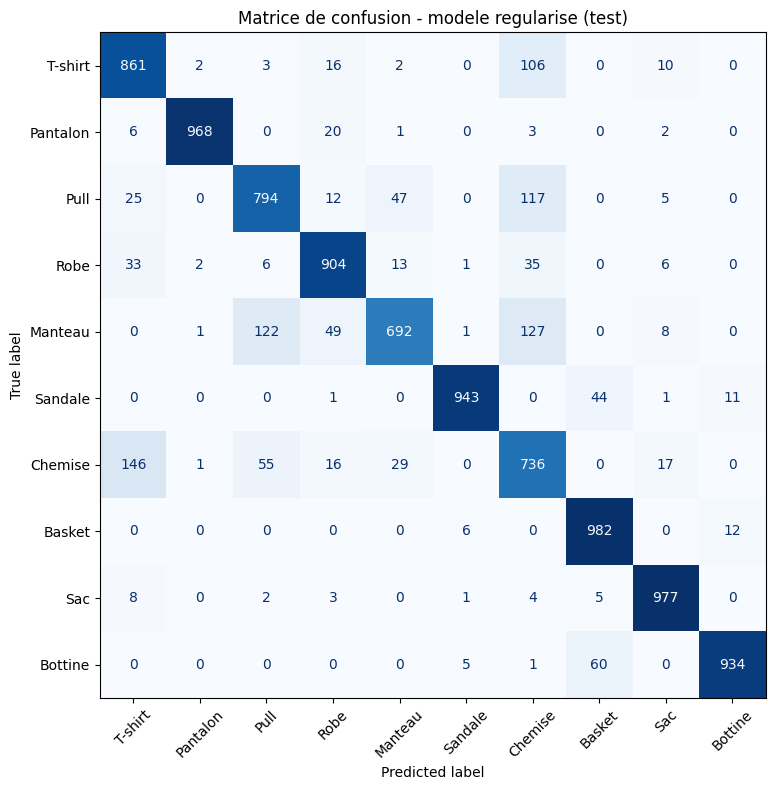

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model_b.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title('Matrice de confusion - modele regularise (test)')
plt.tight_layout(); plt.show()

## 9. A toi de jouer

1. **Dropout** : fais varier le taux (`0.1`, `0.3`, `0.5`). Effet sur l'ecart train/val ?
2. **Early stopping** : ajoute `keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)` au `fit` de la baseline.
3. **AdamW** : remplace l'optimiseur par `keras.optimizers.AdamW(1e-3, weight_decay=1e-4)`.
4. **Scheduler** : ajoute `keras.callbacks.ReduceLROnPlateau(patience=2)`.
5. **Question** : a partir de quelle epoque la baseline commence-t-elle a sur-apprendre ?

> Note tes resultats dans un petit tableau (config -> accuracy test, ecart train/val).

In [13]:
# Ton espace d'experimentation
# ...